In [78]:
import matplotlib.pyplot as plt
from solucao import Solucao
from dados import Dados, carrega_dados_json
from scipy.stats import ttest_ind, shapiro, mannwhitneyu

## Pequena

In [79]:
resultados = {"alcione": [], "cartola": [], "chicobuarque": [], "djavan": [], 
              "seujorge": [], "gurobi": []}

nome_instancia = "pequena"
instancia = carrega_dados_json(f"dados/{nome_instancia}.json")

for nome in resultados.keys():
    
    if nome == "gurobi":
        solucao = Solucao()
        solucao.carregar(f"dados/otimo_{nome_instancia}.json")
        resultados[nome].append(solucao.fx)

    else:
        for i in range(30):
            solucao = Solucao()
            solucao.carregar(f"resultados/{nome_instancia}/{nome}/s{i+1}.json")
            if solucao.factivel(instancia, verbose=False):
                resultados[nome].append(solucao.fx)
                
# Imprimir a quantidade de soluções factíveis de cada algoritmo
print(f"Quantidade de soluções factíveis para instância '{nome_instancia}':")
for nome, valores in resultados.items():
    if nome == "gurobi":
        continue
    print(f"  {nome}: {len(valores)} soluções")

Quantidade de soluções factíveis para instância 'pequena':
  alcione: 30 soluções
  cartola: 30 soluções
  chicobuarque: 30 soluções
  djavan: 30 soluções
  seujorge: 29 soluções


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


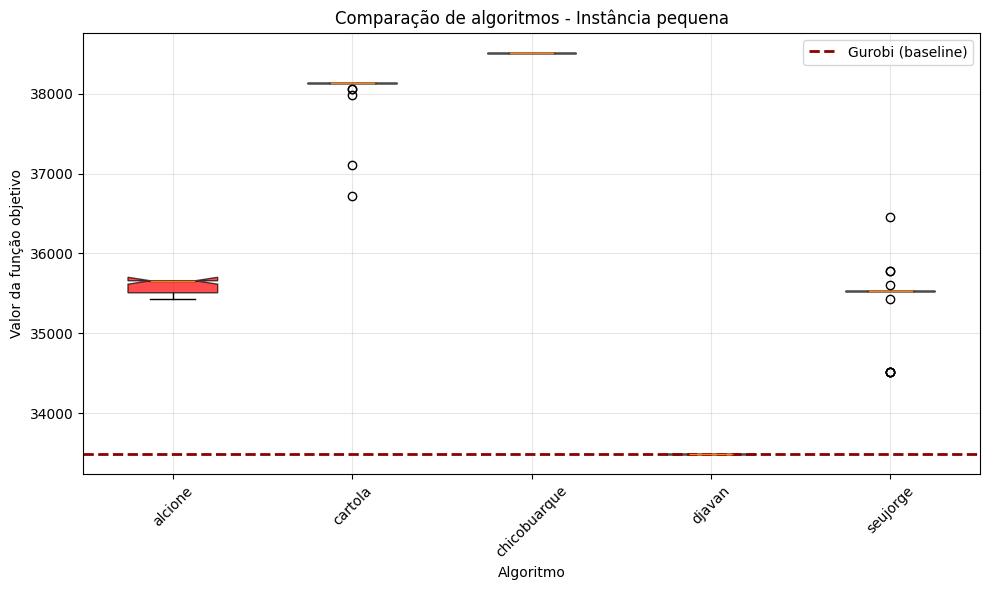

In [80]:
# Preparar os dados para o boxplot (excluindo gurobi)
dados_boxplot = [resultados[nome] for nome in resultados.keys() if nome != "gurobi"]
labels_boxplot = [nome for nome in resultados.keys() if nome != "gurobi"]

# Criar o boxplot
plt.figure(figsize=(10, 6))
bp = plt.boxplot(dados_boxplot, tick_labels=labels_boxplot, notch=True, 
            patch_artist=True)

# Colorir os boxes de vermelho
for patch in bp['boxes']:
    patch.set_facecolor('red')
    patch.set_alpha(0.7)

# Adicionar linha horizontal para o Gurobi (baseline)
valor_gurobi = resultados["gurobi"][0]
plt.axhline(y=valor_gurobi, color='darkred', linestyle='--', linewidth=2, label='Gurobi (baseline)')

plt.ylabel('Valor da função objetivo')
plt.xlabel('Algoritmo')
plt.title(f'Comparação de algoritmos - Instância {nome_instancia}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'./resultados/apresentacao/boxplot_{nome_instancia}.eps', 
            format='eps', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

## Média

In [81]:
resultados = {"alcione": [], "cartola": [], "chicobuarque": [], "djavan": [], 
              "seujorge": [], "gurobi": []}

nome_instancia = "media"
instancia = carrega_dados_json(f"dados/{nome_instancia}.json")

for nome in resultados.keys():
    
    if nome == "gurobi":
        solucao = Solucao()
        solucao.carregar(f"dados/otimo_{nome_instancia}.json")
        resultados[nome].append(solucao.fx)

    else:
        for i in range(30):
            solucao = Solucao()
            solucao.carregar(f"resultados/{nome_instancia}/{nome}/s{i+1}.json")
            if solucao.factivel(instancia, verbose=False):
                resultados[nome].append(solucao.fx)

# Imprimir a quantidade de soluções factíveis de cada algoritmo
print(f"Quantidade de soluções factíveis para instância '{nome_instancia}':")
for nome, valores in resultados.items():
    if nome == "gurobi":
        continue
    print(f"  {nome}: {len(valores)} soluções")

Quantidade de soluções factíveis para instância 'media':
  alcione: 30 soluções
  cartola: 30 soluções
  chicobuarque: 30 soluções
  djavan: 30 soluções
  seujorge: 30 soluções


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


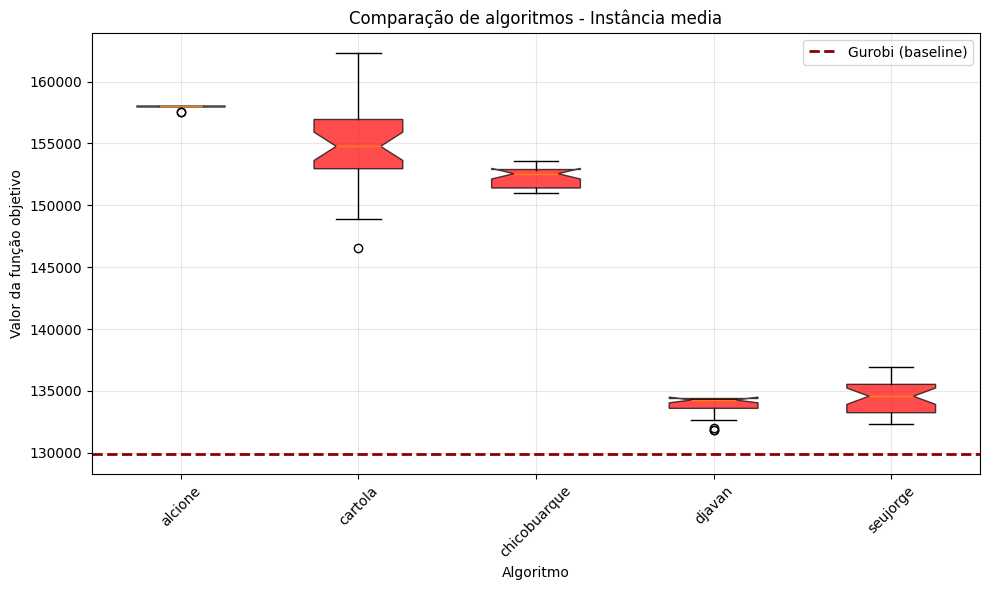

In [82]:
# Preparar os dados para o boxplot (excluindo gurobi)
dados_boxplot = [resultados[nome] for nome in resultados.keys() if nome != "gurobi"]
labels_boxplot = [nome for nome in resultados.keys() if nome != "gurobi"]

# Criar o boxplot
plt.figure(figsize=(10, 6))
bp = plt.boxplot(dados_boxplot, tick_labels=labels_boxplot, notch=True,
            patch_artist=True)

# Colorir os boxes de vermelho
for patch in bp['boxes']:
    patch.set_facecolor('red')
    patch.set_alpha(0.7)

# Adicionar linha horizontal para o Gurobi (baseline)
valor_gurobi = resultados["gurobi"][0]
plt.axhline(y=valor_gurobi, color='darkred', linestyle='--', linewidth=2, label='Gurobi (baseline)')

plt.ylabel('Valor da função objetivo')
plt.xlabel('Algoritmo')
plt.title(f'Comparação de algoritmos - Instância {nome_instancia}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'./resultados/apresentacao/boxplot_{nome_instancia}.eps', 
            format='eps', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [83]:
y1 = resultados["djavan"]
y2 = resultados["seujorge"]

# Teste de normalidade de Shapiro-Wilk
stat1, p1 = shapiro(y1)
stat2, p2 = shapiro(y2)
alpha = 0.05
if p1 > alpha:
    print("As amostras de 'djavan' parecem vir de uma distribuição normal (falha em rejeitar H0)")
else:
    print("As amostras de 'djavan' não parecem vir de uma distribuição normal (rejeita H0)")
if p2 > alpha:
    print("As amostras de 'seujorge' parecem vir de uma distribuição normal (falha em rejeitar H0)")
else:
    print("As amostras de 'seujorge' não parecem vir de uma distribuição normal (rejeita H0)")

# Teste t de Student ou teste de Mann-Whitney U
if p1 > alpha and p2 > alpha:
    stat, p = ttest_ind(y1, y2)
    print("Teste t de Student:")
    print(f"Estatística={stat}, p-valor={p}")
    if p > alpha:
        print("As médias dos dois grupos são iguais (falha em rejeitar H0)")
    else:
        print("As médias dos dois grupos são diferentes (rejeita H0)")
else:
    stat, p = mannwhitneyu(y1, y2)
    print("Teste de Mann-Whitney U:")
    print(f"Estatística={stat}, p-valor={p}")
    if p > alpha:
        print("As distribuições dos dois grupos são iguais (falha em rejeitar H0)")
    else:
        print("As distribuições dos dois grupos são diferentes (rejeita H0)")

As amostras de 'djavan' não parecem vir de uma distribuição normal (rejeita H0)
As amostras de 'seujorge' parecem vir de uma distribuição normal (falha em rejeitar H0)
Teste de Mann-Whitney U:
Estatística=338.0, p-valor=0.09753768666519912
As distribuições dos dois grupos são iguais (falha em rejeitar H0)


## Grande

In [84]:
resultados = {"alcione": [], "cartola": [], "chicobuarque": [], "djavan": [], 
              "seujorge": [], "gurobi": []}

nome_instancia = "grande"
instancia = carrega_dados_json(f"dados/{nome_instancia}.json")

for nome in resultados.keys():
    
    if nome == "gurobi":
        solucao = Solucao()
        solucao.carregar(f"dados/otimo_{nome_instancia}.json")
        resultados[nome].append(solucao.fx)
        
    elif nome == "alcione":
        continue

    else:
        for i in range(30):
            solucao = Solucao()
            solucao.carregar(f"resultados/{nome_instancia}/{nome}/s{i+1}.json")
            if solucao.factivel(instancia, verbose=False):
                resultados[nome].append(solucao.fx)
                
# Imprimir a quantidade de soluções factíveis de cada algoritmo
print(f"Quantidade de soluções factíveis para instância '{nome_instancia}':")
for nome, valores in resultados.items():
    if nome == "gurobi":
        continue
    print(f"  {nome}: {len(valores)} soluções")

Quantidade de soluções factíveis para instância 'grande':
  alcione: 0 soluções
  cartola: 30 soluções
  chicobuarque: 30 soluções
  djavan: 29 soluções
  seujorge: 30 soluções


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


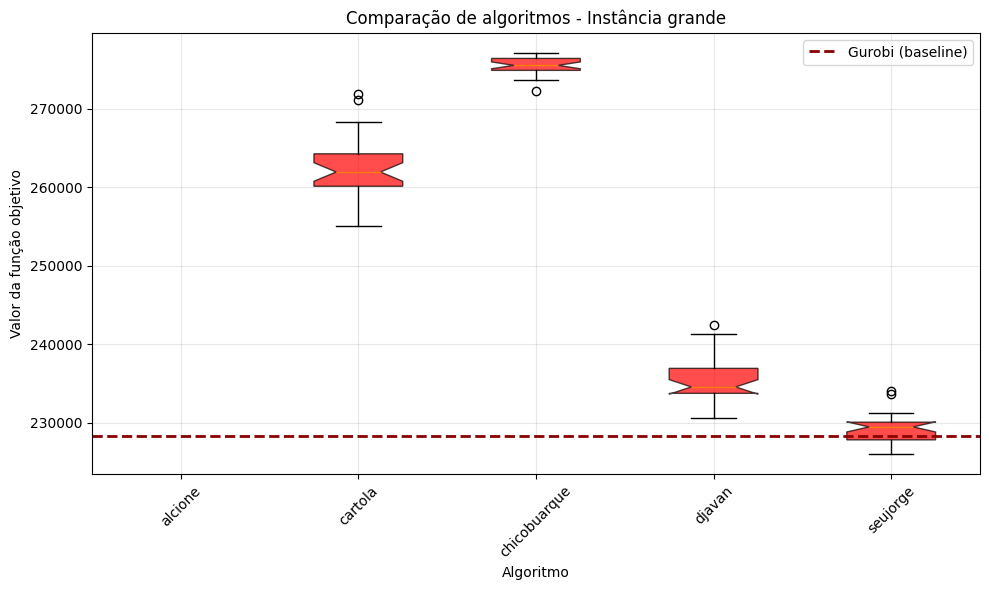

In [85]:
# Preparar os dados para o boxplot (excluindo gurobi)
dados_boxplot = [resultados[nome] for nome in resultados.keys() if nome != "gurobi"]
labels_boxplot = [nome for nome in resultados.keys() if nome != "gurobi"]

# Criar o boxplot
plt.figure(figsize=(10, 6))
bp = plt.boxplot(dados_boxplot, tick_labels=labels_boxplot, notch=True,
            patch_artist=True)

# Colorir os boxes de vermelho
for patch in bp['boxes']:
    patch.set_facecolor('red')
    patch.set_alpha(0.7)

# Adicionar linha horizontal para o Gurobi (baseline)
valor_gurobi = resultados["gurobi"][0]
plt.axhline(y=valor_gurobi, color='darkred', linestyle='--', linewidth=2, label='Gurobi (baseline)')

plt.ylabel('Valor da função objetivo')
plt.xlabel('Algoritmo')
plt.title(f'Comparação de algoritmos - Instância {nome_instancia}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'./resultados/apresentacao/boxplot_{nome_instancia}.eps', 
            format='eps', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [86]:
y1 = resultados["djavan"]
y2 = resultados["seujorge"]

# Teste de normalidade de Shapiro-Wilk
stat1, p1 = shapiro(y1)
stat2, p2 = shapiro(y2)
alpha = 0.05
if p1 > alpha:
    print("As amostras de 'djavan' parecem vir de uma distribuição normal (falha em rejeitar H0)")
else:
    print("As amostras de 'djavan' não parecem vir de uma distribuição normal (rejeita H0)")
if p2 > alpha:
    print("As amostras de 'seujorge' parecem vir de uma distribuição normal (falha em rejeitar H0)")
else:
    print("As amostras de 'seujorge' não parecem vir de uma distribuição normal (rejeita H0)")

# Teste t de Student ou teste de Mann-Whitney U
if p1 > alpha and p2 > alpha:
    stat, p = ttest_ind(y1, y2, equal_var=False, alternative='greater')
    print("Teste t de Student:")
    print(f"Estatística={stat}, p-valor={p}")
    if p > alpha:
        print("As médias dos dois grupos são iguais (falha em rejeitar H0)")
    else:
        print("As médias dos dois grupos são diferentes (rejeita H0)")
else:
    stat, p = mannwhitneyu(y1, y2)
    print("Teste de Mann-Whitney U:")
    print(f"Estatística={stat}, p-valor={p}")
    if p > alpha:
        print("As distribuições dos dois grupos são iguais (falha em rejeitar H0)")
    else:
        print("As distribuições dos dois grupos são diferentes (rejeita H0)")

As amostras de 'djavan' parecem vir de uma distribuição normal (falha em rejeitar H0)
As amostras de 'seujorge' parecem vir de uma distribuição normal (falha em rejeitar H0)
Teste t de Student:
Estatística=9.394058956986903, p-valor=1.4375004813515517e-12
As médias dos dois grupos são diferentes (rejeita H0)


## Rush

In [87]:
resultados = {"alcione": [], "cartola": [], "chicobuarque": [], "djavan": [], 
              "seujorge": [], "gurobi": []}

nome_instancia = "rush"
instancia = carrega_dados_json(f"dados/{nome_instancia}.json")

for nome in resultados.keys():
    
    if nome == "gurobi":
        solucao = Solucao()
        solucao.carregar(f"dados/otimo_{nome_instancia}.json")
        resultados[nome].append(solucao.fx)
        
    elif nome == "alcione":
        continue

    else:
        for i in range(30):
            solucao = Solucao()
            solucao.carregar(f"resultados/{nome_instancia}/{nome}/s{i+1}.json")
            if solucao.factivel(instancia, verbose=False):
                resultados[nome].append(solucao.fx)
                
# Imprimir a quantidade de soluções factíveis de cada algoritmo
print(f"Quantidade de soluções factíveis para instância '{nome_instancia}':")
for nome, valores in resultados.items():
    if nome == "gurobi":
        continue
    print(f"  {nome}: {len(valores)} soluções")

Quantidade de soluções factíveis para instância 'rush':
  alcione: 0 soluções
  cartola: 30 soluções
  chicobuarque: 18 soluções
  djavan: 30 soluções
  seujorge: 30 soluções


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


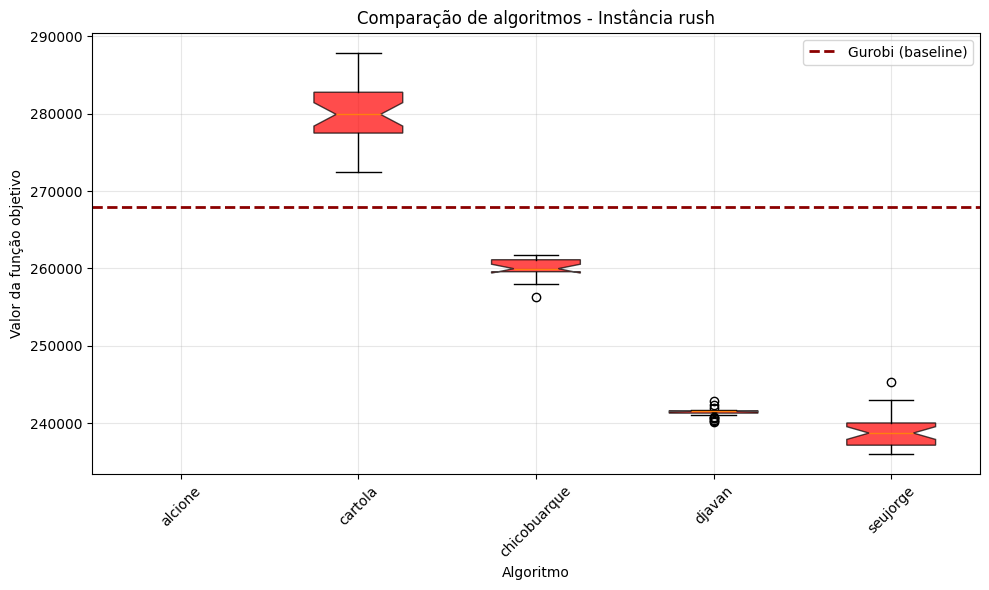

In [88]:
# Preparar os dados para o boxplot (excluindo gurobi)
dados_boxplot = [resultados[nome] for nome in resultados.keys() if nome != "gurobi"]
labels_boxplot = [nome for nome in resultados.keys() if nome != "gurobi"]

# Criar o boxplot
plt.figure(figsize=(10, 6))
bp = plt.boxplot(dados_boxplot, tick_labels=labels_boxplot, notch=True,
            patch_artist=True)

# Colorir os boxes de vermelho
for patch in bp['boxes']:
    patch.set_facecolor('red')
    patch.set_alpha(0.7)

# Adicionar linha horizontal para o Gurobi (baseline)
valor_gurobi = resultados["gurobi"][0]
plt.axhline(y=valor_gurobi, color='darkred', linestyle='--', linewidth=2, label='Gurobi (baseline)')

plt.ylabel('Valor da função objetivo')
plt.xlabel('Algoritmo')
plt.title(f'Comparação de algoritmos - Instância {nome_instancia}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'./resultados/apresentacao/boxplot_{nome_instancia}.eps', 
            format='eps', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [89]:
y1 = resultados["djavan"]
y2 = resultados["seujorge"]

# Teste de normalidade de Shapiro-Wilk
stat1, p1 = shapiro(y1)
stat2, p2 = shapiro(y2)
alpha = 0.05
if p1 > alpha:
    print("As amostras de 'djavan' parecem vir de uma distribuição normal (falha em rejeitar H0)")
else:
    print("As amostras de 'djavan' não parecem vir de uma distribuição normal (rejeita H0)")
if p2 > alpha:
    print("As amostras de 'seujorge' parecem vir de uma distribuição normal (falha em rejeitar H0)")
else:
    print("As amostras de 'seujorge' não parecem vir de uma distribuição normal (rejeita H0)")

# Teste t de Student ou teste de Mann-Whitney U
if p1 > alpha and p2 > alpha:
    stat, p = ttest_ind(y1, y2, equal_var=False, alternative='greater')
    print("Teste t de Student:")
    print(f"Estatística={stat}, p-valor={p}")
    if p > alpha:
        print("As médias dos dois grupos são iguais (falha em rejeitar H0)")
    else:
        print("As médias dos dois grupos são diferentes (rejeita H0)")
else:
    stat, p = mannwhitneyu(y1, y2)
    print("Teste de Mann-Whitney U:")
    print(f"Estatística={stat}, p-valor={p}")
    if p > alpha:
        print("As distribuições dos dois grupos são iguais (falha em rejeitar H0)")
    else:
        print("As distribuições dos dois grupos são diferentes (rejeita H0)")

As amostras de 'djavan' não parecem vir de uma distribuição normal (rejeita H0)
As amostras de 'seujorge' não parecem vir de uma distribuição normal (rejeita H0)
Teste de Mann-Whitney U:
Estatística=782.0, p-valor=8.392528584192757e-07
As distribuições dos dois grupos são diferentes (rejeita H0)
